# AI-ML Assignment – 1

## Medical Insurance Cost Prediction using Multiple Linear Regression

### Objective
The objective of this assignment is to develop a Multiple Linear Regression model
to predict medical insurance charges based on customers' personal and health-related
information such as age, sex, BMI, number of children, smoking status, and region.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
from google.colab import files

uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [3]:
df = pd.read_csv("insurance.csv")

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nTarget Variable:")
print("charges")

Numerical Features:
['age', 'bmi', 'children', 'charges']

Categorical Features:
['sex', 'smoker', 'region']

Target Variable:
charges


In [7]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [8]:
X = df[['age', 'sex', 'bmi', 'children', 'smoker', 'region']]
y = df['charges']

In [9]:
numerical_columns = ['age', 'bmi', 'children']
categorical_columns = ['sex', 'smoker', 'region']

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_columns)
    ],
    remainder='passthrough'
)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (1070, 6)
Testing data size: (268, 6)


In [12]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [13]:
model = LinearRegression()

model.fit(X_train_encoded, y_train)

LinearRegression()

In [14]:
y_pred = model.predict(X_test_encoded)

print("Predicted Insurance Charges:")
print(y_pred[:10])

Predicted Insurance Charges:
[ 8969.55027444  7068.74744287 36858.41091155  9454.67850053
 26973.17345656 10864.11316424   170.28084137 16903.45028662
  1092.43093614 11218.34318352]


In [15]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)

Model Evaluation Results
------------------------
Mean Absolute Error (MAE): 4181.194473753643
Mean Squared Error (MSE): 33596915.85136148
R2 Score: 0.7835929767120722


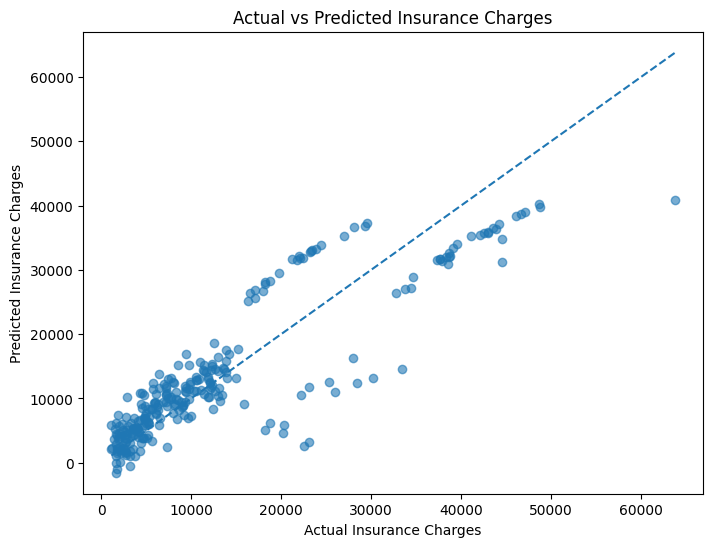

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Insurance Charges")
plt.ylabel("Predicted Insurance Charges")
plt.title("Actual vs Predicted Insurance Charges")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()

### Observations

1. The model achieved an R² score of approximately 0.78, indicating that the selected
features explain a significant portion of the variation in medical insurance charges.

2. The MAE indicates that the model's predictions differ from the actual insurance
charges by approximately $4,000 on average.

3. The Actual vs Predicted scatter plot shows that the model performs reasonably well
for many observations, but some predictions deviate considerably from the ideal
prediction line. This suggests that some factors affecting insurance charges may not
be fully captured by a simple linear relationship.

## Conclusion

In this assignment, a Multiple Linear Regression model was developed to predict medical insurance charges using age, sex, BMI, number of children, smoking status, and region. The dataset was preprocessed by checking for missing values and applying one-hot encoding to categorical variables. The data was then divided into 80% training and 20% testing sets. The model was evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² Score. The results indicate that factors such as age, BMI, and especially smoking status have a considerable influence on insurance charges. The model provides reasonably good predictions but may not capture complex non-linear relationships between variables. A major limitation of Linear Regression is its assumption of a linear relationship, which may not accurately represent all factors affecting medical insurance costs.


## Final Summary

The Multiple Linear Regression model was successfully developed to predict medical
insurance charges. The model used both numerical and categorical features and
demonstrated reasonable predictive performance based on MAE, MSE, and R² Score.
Smoking status, age, and BMI were identified as important factors influencing
insurance charges.